<a target="_blank" href="https://colab.research.google.com/github/binsue0/.github/blob/main/ML_day1/1_3_performanceMeasure.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# 분류 성능 평가

ref: https://github.com/codingalzi/handson-ml2/blob/master/notebooks/handson-ml2-03.ipynb

**"이 숫자가 5인가?"** 를 맞히는 이진 분류기를 만들고, 그 성능을 제대로 평가하는 방법을 봅니다.

- 정확도(accuracy)의 함정
- 오차 행렬 → 정밀도 / 재현율 / F1
- 임곗값 트레이드오프
- ROC 곡선과 AUC

## 0. 준비: 데이터와 분류기

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

np.random.seed(42)

# 손글씨 숫자 데이터 (8x8 이미지 1,797장)
digits = load_digits()
X, y = digits.data, digits.target
X.shape, y.shape

((1797, 64), (1797,))

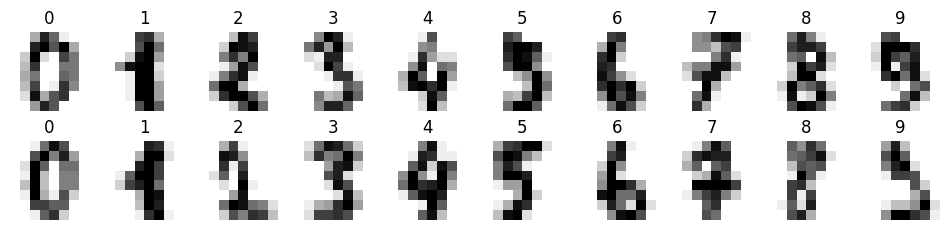

In [2]:
# 앞의 20장만 눈으로 봅니다.
fig, axes = plt.subplots(2, 10, figsize=(12, 2.6))

for ax, img, label in zip(axes.ravel(), X, y):
    ax.imshow(img.reshape(8, 8), cmap='binary')
    ax.set_title(int(label))
    ax.axis('off')

plt.show()

이제 **"5인가, 아닌가"** 만 맞히는 이진 분류 문제로 바꿉니다.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5이면 True, 아니면 False
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

print('훈련 데이터:', len(y_train_5), '개 중 5는', y_train_5.sum(), '개')

훈련 데이터: 1437 개 중 5는 135 개


In [4]:
# 확률적 경사 하강법(SGD) 분류기를 학습시킵니다.
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

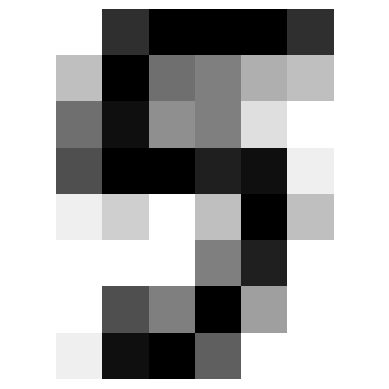

예측: [ True] / 정답: True


In [5]:
# 실제로 5인 샘플을 하나 골라 맞히는지 봅니다.
i = np.argmax(y_train_5)

plt.imshow(X_train[i].reshape(8, 8), cmap='binary')
plt.axis('off')
plt.show()

print('예측:', sgd_clf.predict([X_train[i]]), '/ 정답:', y_train_5[i])

## 1. 정확도(accuracy)의 함정

In [6]:
# 교차 검증으로 정확도를 봅니다.
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.98121086, 0.98538622, 0.98956159])

99% 가까이 나왔네요. 좋은 모델일까요? **속단하면 안 됩니다.**

In [7]:
# 무조건 "5가 아니다"라고만 답하는 바보 분류기를 만들어 봅시다.
from sklearn.dummy import DummyClassifier

never_5 = DummyClassifier(strategy='most_frequent')
cross_val_score(never_5, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.90605428, 0.90605428, 0.90605428])

아무것도 안 하는 분류기도 **90%** 입니다. 전체의 10%만 5이기 때문이죠.

이렇게 **클래스가 한쪽으로 치우친(imbalanced) 데이터**에서는 정확도만 보면 안 됩니다.
그래서 **오차 행렬**을 봅니다.

## 2. 오차 행렬(confusion matrix)

In [8]:
# 교차 검증으로 '점수' 대신 '예측값'을 받아옵니다.
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[1298,    4],
       [  17,  118]])

```
TN | FP
---|---
FN | TP
```

- **TN**: 5가 아닌 걸 아니라고 맞힘
- **FP**: 5가 아닌데 5라고 잘못 말함 (헛다리)
- **FN**: 5인데 아니라고 놓침
- **TP**: 5를 5라고 맞힘

완벽한 분류기라면 대각선(TN, TP)만 남고 나머지는 0이 됩니다.

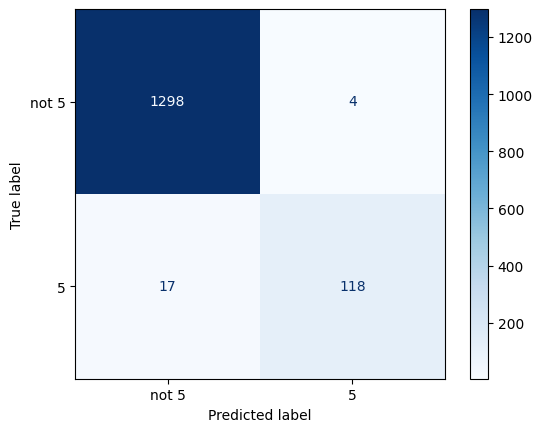

In [9]:
# 그림으로도 볼 수 있습니다.
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(cm, display_labels=['not 5', '5']).plot(cmap='Blues')
plt.show()

## 3. 정밀도 · 재현율 · F1

$$\text{정밀도} = \frac{TP}{TP + FP} \qquad
\text{재현율} = \frac{TP}{TP + FN} \qquad
F_1 = \frac{2}{\frac{1}{\text{정밀도}} + \frac{1}{\text{재현율}}}$$

- **정밀도(precision)**: 5라고 말한 것 중 진짜 5의 비율 → *"내 말이 얼마나 믿을 만한가"*
- **재현율(recall)**: 진짜 5 중에서 찾아낸 비율 → *"놓치지 않고 얼마나 잡아냈나"*
- **F1**: 둘의 조화평균. 한쪽만 높으면 점수가 낮아집니다.

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('정밀도:', precision_score(y_train_5, y_train_pred))
print('재현율:', recall_score(y_train_5, y_train_pred))
print('F1    :', f1_score(y_train_5, y_train_pred))

정밀도: 0.9672131147540983
재현율: 0.8740740740740741
F1    : 0.9182879377431906


In [11]:
# 오차 행렬에서 직접 계산해도 같습니다.
tn, fp, fn, tp = cm.ravel()

print('정밀도:', tp / (tp + fp))
print('재현율:', tp / (tp + fn))
print('F1    :', tp / (tp + (fn + fp) / 2))

정밀도: 0.9672131147540983
재현율: 0.8740740740740741
F1    : 0.9182879377431906


In [12]:
# 한 번에 보고 싶다면
from sklearn.metrics import classification_report

print(classification_report(y_train_5, y_train_pred, target_names=['not 5', '5']))

              precision    recall  f1-score   support

       not 5       0.99      1.00      0.99      1302
           5       0.97      0.87      0.92       135

    accuracy                           0.99      1437
   macro avg       0.98      0.94      0.96      1437
weighted avg       0.99      0.99      0.99      1437



## 4. 정밀도/재현율 트레이드오프

분류기는 사실 각 샘플에 **점수**를 매긴 뒤, 그 점수가 **임계값(threshold)** 보다 크면 양성이라고 판정합니다.
임곗값을 올리면 정밀도는 올라가고 재현율은 떨어집니다. (반대도 마찬가지)

In [13]:
# 아까 그 5 한 장 + 5가 아닌 두 장의 점수를 봅니다.
scores = sgd_clf.decision_function(X_train[[i, 0, 1]])

print('점수        :', scores.round(1))
print('임곗값 0    :', scores > 0)
print('임곗값 2000 :', scores > 2000)

점수        : [ 3029.9 -1091.4 -1795.3]
임곗값 0    : [ True False False]
임곗값 2000 : [ True False False]


임곗값을 2000으로 올리자 진짜 5를 **놓쳤습니다**. 대신 헛다리를 짚을 일도 줄어들죠.

In [14]:
# 모든 훈련 샘플의 점수를 교차 검증으로 구합니다.
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method='decision_function')

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

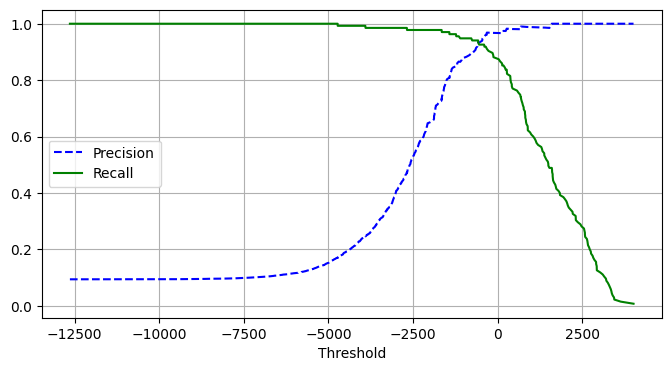

In [15]:
# 임곗값에 따라 정밀도와 재현율이 어떻게 움직이는지 봅니다.
plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.grid(True)
plt.show()

왼쪽으로 갈수록(임곗값 낮음) 다 잡아내지만 헛다리도 많고,
오른쪽으로 갈수록(임곗값 높음) 확실한 것만 말하지만 많이 놓칩니다.

목적에 따라 고르면 됩니다.
암 진단이라면 **재현율**(놓치면 큰일), 스팸 분류라면 **정밀도**(멀쩡한 메일을 버리면 안 됨)를 높입니다.

In [16]:
# 정밀도 99%를 만드는 임곗값을 찾아 적용해 봅니다.
idx = np.argmax(precisions >= 0.99)
threshold_99 = thresholds[idx]

y_pred_99 = (y_scores >= threshold_99)

print('임곗값:', threshold_99.round(2))
print('정밀도:', precision_score(y_train_5, y_pred_99))
print('재현율:', recall_score(y_train_5, y_pred_99))

임곗값: 682.73
정밀도: 0.9900990099009901
재현율: 0.7407407407407407


## 5. ROC 곡선과 AUC

$$\text{TPR(재현율)} = \frac{TP}{FN + TP} \qquad
\text{FPR} = \frac{FP}{TN + FP}$$

ROC 곡선은 임곗값을 움직이며 **TPR과 FPR의 관계**를 그린 것입니다.
왼쪽 위 모서리에 가까울수록 좋고, 대각선 점선은 **찍기(random)** 수준입니다.
곡선 아래 면적이 **AUC**이며 1에 가까울수록 좋습니다.

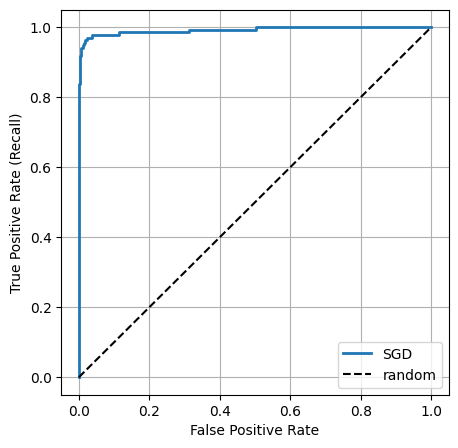

AUC: 0.9916197303294078


In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_train_5, y_scores)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, linewidth=2, label='SGD')
plt.plot([0, 1], [0, 1], 'k--', label='random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.grid(True)
plt.show()

print('AUC:', roc_auc_score(y_train_5, y_scores))

AUC가 좋은 이유는 **모델끼리 비교하기 쉽다**는 점입니다. 랜덤 포레스트와 비교해 봅시다.

In [18]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# 랜덤 포레스트는 decision_function 대신 확률(predict_proba)을 줍니다.
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method='predict_proba')
y_scores_forest = y_probas_forest[:, 1]

fpr_f, tpr_f, _ = roc_curve(y_train_5, y_scores_forest)

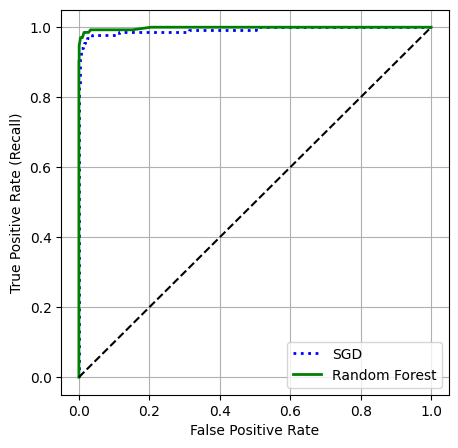

SGD           AUC: 0.9916197303294078
RandomForest  AUC: 0.9981765944131535


In [19]:
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, 'b:', linewidth=2, label='SGD')
plt.plot(fpr_f, tpr_f, 'g-', linewidth=2, label='Random Forest')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.grid(True)
plt.show()

print('SGD           AUC:', roc_auc_score(y_train_5, y_scores))
print('RandomForest  AUC:', roc_auc_score(y_train_5, y_scores_forest))

랜덤 포레스트 곡선이 왼쪽 위에 더 붙어 있고 AUC도 높습니다. 더 좋은 모델이라는 뜻입니다.

## 정리

| 지표 | 뜻 | 언제 보나 |
|---|---|---|
| 정확도 | 전체 중 맞힌 비율 | 클래스가 균형 잡혀 있을 때만 |
| 정밀도 | 양성이라 한 것 중 진짜 | 헛다리가 비쌀 때 (스팸 분류) |
| 재현율 | 진짜 양성 중 찾아낸 것 | 놓치면 안 될 때 (암 진단) |
| F1 | 정밀도·재현율의 조화평균 | 둘 다 챙기고 싶을 때 |
| AUC | ROC 곡선 아래 면적 | 모델끼리 비교할 때 |

핵심 두 가지
1. 데이터가 치우쳐 있으면 **정확도는 거짓말**을 한다 → 오차 행렬부터 본다
2. 정밀도와 재현율은 **동시에 올릴 수 없다** → 임계값으로 목적에 맞게 조절한다
